# Population variability notebook

This notebook computes two per-synapse metrics from the single-trial `image_identity` responses:

1. **Within-image variance**: mean trial-to-trial variance across repeated presentations of the same image  
2. **Between-image variance**: variance of the per-image mean responses across images

It follows the same session/asset loading style as your FVE notebook and merges the output back onto the activation table so each row keeps `session_id`, `session_type`, `dmd`, `synapse_id`, `response_class`, and the DMD-derived `depth`.


In [1]:

import os
import glob
import warnings
import numpy as np
import pandas as pd
import itertools
from pathlib import Path
from PNW_cmap import PNW_cmap
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry

sns.set_style('white')
params = {
    'legend.fontsize': 'x-large',
    'axes.labelsize': 'xx-large',
    'axes.titlesize': 'xx-large',
    'xtick.labelsize': 'xx-large',
    'ytick.labelsize': 'xx-large'
}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))


In [2]:

%load_ext autoreload
%autoreload 2
%matplotlib notebook


In [3]:
savepath = r'C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Data_Club\April2026\figures'

In [4]:

target_mice = [
    803496,
    804730, 804733, 810196,
    809047, 803121,
    826033, 838410, 834788,
]

registry = VIPSessionRegistry.from_basepath(
    r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics'
)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=["expression_check", "volume_imaging"],
    paradigms=["change_detection_passive"],
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Loaded {len(assets)} session assets")


Loaded 56 session assets


In [5]:

st_paths = [
    glob.glob(os.path.join(asset.derived_dir, '**', 'glutamate_single_trial_df.npz'), recursive=True)[0]
    for asset in assets
]

act_summary_path = r"C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Data_Club\April2026\data\activation_summary.csv"
act_summary = pd.read_csv(act_summary_path)

# one row per synapse in your activation table; keep all activation metadata
act_summary = act_summary.drop(columns=[c for c in act_summary.columns if c.startswith('Unnamed:')], errors='ignore')
activation_synapses = act_summary.drop_duplicates(['session_id', 'dmd', 'synapse_id']).copy()

display(activation_synapses.head())
print(f"{len(activation_synapses)} unique synapses in activation table")


,session_id,subject_id,dmd,synapse_id,stimulus_family,n_events,median_delta_auc,mean_delta_auc,effect_direction,p_value,response_class,q_value_within_synapse
0,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0000,image,2277,-20.015213,-23.085767,none,3.356907e-02,no_change,1.007072e-01
1,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0001,image,2277,11.062568,10.113008,none,1.885622e-01,no_change,3.431282e-01
2,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0002,image,2277,62.247024,75.345806,up,1.833899e-10,activated,5.501698e-10
3,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0003,image,2277,51.070708,94.594795,up,5.779422e-15,activated,1.733827e-14
4,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0004,image,2277,-94.736861,-159.029189,down,1.601894e-34,deactivated,4.805682e-34


6992 unique synapses in activation table


In [6]:

def _safe_first(glob_result):
    return glob_result[0] if len(glob_result) else np.nan


asset_rows = []
for (_, row), asset, st_path in zip(process_df.iterrows(), assets, st_paths):
    meta = getattr(asset, 'metadata', {}) or {}
    session_id = getattr(asset, 'session_id', row.get('session_id', Path(getattr(asset, 'session_dir', '')).name))

    session_type = row.get('session_type', np.nan)
    if pd.isna(session_type):
        session_type = getattr(asset, 'session_type', meta.get('session_type', np.nan))

    subject_id = row.get('subject_id', np.nan)
    if pd.isna(subject_id):
        subject_id = getattr(asset, 'subject_id', meta.get('subject_id', np.nan))

    asset_rows.append({
        'session_id': session_id,
        'subject_id': subject_id,
        'session_type': session_type,
        'session_dir': getattr(asset, 'session_dir', np.nan),
        'derived_dir': getattr(asset, 'derived_dir', np.nan),
        'st_path': st_path,
        'dmd1_depth': meta.get('dmd1_depth', np.nan),
        'dmd2_depth': meta.get('dmd2_depth', np.nan),
    })

asset_table = pd.DataFrame(asset_rows).drop_duplicates('session_id').copy()
display(asset_table.head())


,session_id,subject_id,session_type,session_dir,derived_dir,st_path,dmd1_depth,dmd2_depth
0,803496_2025-07-25_13-02-10,803496,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,25,100
1,803496_2025-07-28_08-04-39,803496,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,25,100
2,803496_2025-07-29_13-34-35,803496,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,25,100
3,803496_2025-07-30_10-05-23,803496,novel,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,25,100
4,803496_2025-07-31_09-43-28,803496,novel+,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,25,100


In [7]:

# Merge session_type onto the synapse table now, before computing variability
activation_synapses = activation_synapses.merge(
    asset_table[['session_id', 'session_type', 'dmd1_depth', 'dmd2_depth']],
    on='session_id',
    how='left',
)

activation_synapses['depth'] = np.where(
    activation_synapses['dmd'].eq('DMD1'),
    activation_synapses['dmd1_depth'],
    activation_synapses['dmd2_depth'],
)

display(activation_synapses.head())


,session_id,subject_id,dmd,synapse_id,stimulus_family,n_events,median_delta_auc,mean_delta_auc,effect_direction,p_value,response_class,q_value_within_synapse,session_type,dmd1_depth,dmd2_depth,depth
0,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0000,image,2277,-20.015213,-23.085767,none,3.356907e-02,no_change,1.007072e-01,familiar,25,100,25
1,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0001,image,2277,11.062568,10.113008,none,1.885622e-01,no_change,3.431282e-01,familiar,25,100,25
2,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0002,image,2277,62.247024,75.345806,up,1.833899e-10,activated,5.501698e-10,familiar,25,100,25
3,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0003,image,2277,51.070708,94.594795,up,5.779422e-15,activated,1.733827e-14,familiar,25,100,25
4,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0004,image,2277,-94.736861,-159.029189,down,1.601894e-34,deactivated,4.805682e-34,familiar,25,100,25


## Variability settings

By default this uses a **baseline-subtracted post-stimulus mean** as the trial amplitude:

- baseline window: `0:50`
- response window: `50:100`

At 200 Hz this is:
- baseline: `0.00–0.25 s`
- response: `0.25–0.50 s`

If you want strict parity with the earlier FVE notebook, set `baseline_slice = None` and it will use the raw post-stimulus mean only.


In [8]:

response_slice = (50, 100)
baseline_slice = (0, 50)   # set to None for post-only amplitudes
min_trials_per_image = 2   # minimum valid repeated trials required for a given image


In [19]:

def nanmean_no_warning(x, axis):
    x = np.asarray(x, dtype=float)
    count = np.sum(~np.isnan(x), axis=axis)
    total = np.nansum(x, axis=axis)

    out = np.full(np.shape(total), np.nan, dtype=float)
    np.divide(total, count, out=out, where=count > 0)
    return out


def nanvar_no_warning(x, axis, ddof=0):
    x = np.asarray(x, dtype=float)
    mean = nanmean_no_warning(x, axis=axis)
    mean_expanded = np.expand_dims(mean, axis=axis)

    sq = (x - mean_expanded) ** 2
    count = np.sum(~np.isnan(x), axis=axis)
    total = np.nansum(sq, axis=axis)

    denom = count - ddof
    out = np.full(np.shape(total), np.nan, dtype=float)
    np.divide(total, denom, out=out, where=denom > 0)
    return out


def compute_trial_amplitudes(traces, response_slice=(50, 100), baseline_slice=(0, 50)):
    """
    Parameters
    ----------
    traces : array, shape (n_trials, n_synapses, n_samples)
    """
    post = nanmean_no_warning(traces[..., response_slice[0]:response_slice[1]], axis=-1)

    if baseline_slice is None:
        return post

    pre = nanmean_no_warning(traces[..., baseline_slice[0]:baseline_slice[1]], axis=-1)
    return post #- pre


In [20]:

def compute_session_variability_from_st(
    st_path,
    activation_synapses_session,
    response_slice=(50, 100),
    baseline_slice=(0, 50),
    min_trials_per_image=2,
):
    """
    Returns one row per synapse with within-image and between-image variance.
    """
    payload = np.load(st_path, allow_pickle=True)['data'][0]
    session_id = payload['metadata']['session_id']

    out_rows = []

    for dmd in ('DMD1', 'DMD2'):
        if dmd not in payload:
            continue

        dmd_payload = payload[dmd]
        synapse_ids = np.asarray(dmd_payload['synapse_ids']).astype(str)
        image_dict = dmd_payload['image_identity']

        # Restrict to synapses that exist in the activation table for this session+dmd
        syn_meta = activation_synapses_session.query("session_id == @session_id and dmd == @dmd").copy()
        if syn_meta.empty:
            continue

        keep_mask = np.isin(synapse_ids, syn_meta['synapse_id'].values)
        if not np.any(keep_mask):
            continue

        kept_synapse_ids = synapse_ids[keep_mask]
        kept_indices = np.where(keep_mask)[0]

        image_names = list(image_dict.keys())
        n_images = len(image_names)
        n_syn = len(kept_synapse_ids)

        image_means = np.full((n_images, n_syn), np.nan, dtype=float)
        image_vars = np.full((n_images, n_syn), np.nan, dtype=float)
        image_counts = np.zeros((n_images, n_syn), dtype=int)

        pooled_trial_values = [[] for _ in range(n_syn)]

        for i, image_name in enumerate(image_names):
            traces = np.asarray(image_dict[image_name], dtype=float)[:, kept_indices, :]
            amps = compute_trial_amplitudes(
                traces,
                response_slice=response_slice,
                baseline_slice=baseline_slice,
            )  # shape (n_trials, n_syn)

            counts = np.sum(~np.isnan(amps), axis=0)
            means = nanmean_no_warning(amps, axis=0)
            variances = nanvar_no_warning(amps, axis=0, ddof=1)

            image_means[i] = means
            image_vars[i] = np.where(counts >= min_trials_per_image, variances, np.nan)
            image_counts[i] = counts

            for j in range(n_syn):
                vals = amps[:, j]
                vals = vals[~np.isnan(vals)]
                if len(vals):
                    pooled_trial_values[j].append(vals)

        within_image_var = nanmean_no_warning(image_vars, axis=0)

        between_image_var = np.full(n_syn, np.nan, dtype=float)
        n_images_used = np.sum(~np.isnan(image_vars), axis=0)
        mean_trials_per_image = nanmean_no_warning(
            np.where(image_counts >= min_trials_per_image, image_counts, np.nan),
            axis=0,
        )

        total_trial_var = np.full(n_syn, np.nan, dtype=float)

        for j in range(n_syn):
            vals = image_means[:, j]
            vals = vals[~np.isnan(vals)]
            if len(vals) >= 2:
                between_image_var[j] = np.var(vals, ddof=1)

            if len(pooled_trial_values[j]):
                pooled = np.concatenate(pooled_trial_values[j])
                if len(pooled) >= 2:
                    total_trial_var[j] = np.var(pooled, ddof=1)

        syn_results = pd.DataFrame({
            'session_id': session_id,
            'dmd': dmd,
            'synapse_id': kept_synapse_ids,
            'within_image_var': within_image_var,
            'between_image_var': between_image_var,
            'total_trial_var': total_trial_var,
            'n_images_used': n_images_used,
            'mean_trials_per_image': mean_trials_per_image,
        })

        syn_results['within_frac_total'] = syn_results['within_image_var'] / syn_results['total_trial_var']
        syn_results['within_to_between_ratio'] = syn_results['within_image_var'] / syn_results['between_image_var']

        syn_results = syn_results.merge(
            syn_meta.drop(columns=['dmd1_depth', 'dmd2_depth'], errors='ignore'),
            on=['session_id', 'dmd', 'synapse_id'],
            how='left',
        )

        out_rows.append(syn_results)

    if out_rows:
        return pd.concat(out_rows, ignore_index=True)

    return pd.DataFrame()


In [21]:

all_var = []

for _, row in asset_table.iterrows():
    st_path = row['st_path']
    session_id = row['session_id']
    print(session_id)

    if pd.isna(st_path) or not os.path.exists(st_path):
        print(f"  missing single-trial file: {st_path}")
        continue

    session_var = compute_session_variability_from_st(
        st_path=st_path,
        activation_synapses_session=activation_synapses,
        response_slice=response_slice,
        baseline_slice=baseline_slice,
        min_trials_per_image=min_trials_per_image,
    )

    if session_var.empty:
        print("  no rows returned")
        continue

    all_var.append(session_var)

variance_df = pd.concat(all_var, ignore_index=True) if all_var else pd.DataFrame()
display(variance_df.head())
print(variance_df.shape)


803496_2025-07-25_13-02-10
803496_2025-07-28_08-04-39
803496_2025-07-29_13-34-35
803496_2025-07-30_10-05-23
803496_2025-07-31_09-43-28
803496_2025-08-01_13-22-49
804730_2025-07-25_14-08-35
804730_2025-07-28_13-57-34
804730_2025-07-29_14-55-04
804730_2025-07-30_11-11-11
804730_2025-07-31_11-45-27
804730_2025-08-01_14-22-38
804733_2025-07-25_15-17-00
804733_2025-07-28_19-00-06
804733_2025-07-29_16-02-24
804733_2025-07-30_12-59-44
804733_2025-07-31_13-29-01
804733_2025-08-01_15-20-32
810196_2025-07-25_16-24-20
810196_2025-07-28_19-59-05
810196_2025-07-29_17-02-41
810196_2025-07-31_08-28-08
810196_2025-07-31_14-19-46
810196_2025-08-01_16-37-27
809047_2025-10-29_10-16-32
809047_2025-10-30_10-06-43
809047_2025-10-31_12-00-50
809047_2025-11-01_17-51-59
809047_2025-11-05_10-13-00
809047_2025-11-06_11-05-31
803121_2025-10-29_11-19-29
803121_2025-10-30_11-13-32
803121_2025-10-31_13-05-26
803121_2025-11-01_19-00-21
803121_2025-11-05_11-16-57
803121_2025-11-06_12-12-23
826033_2026-02-21_09-23-34
8

,session_id,dmd,synapse_id,within_image_var,between_image_var,total_trial_var,n_images_used,mean_trials_per_image,within_frac_total,within_to_between_ratio,...,stimulus_family,n_events,median_delta_auc,mean_delta_auc,effect_direction,p_value,response_class,q_value_within_synapse,session_type,depth
0,803496_2025-07-25_13-02-10,DMD1,DMD1_syn0000,63.761221,0.337748,63.706296,7,325.285714,1.000862,188.783536,...,image,2277,-20.015213,-23.085767,none,3.356907e-02,no_change,1.007072e-01,familiar,25
1,803496_2025-07-25_13-02-10,DMD1,DMD1_syn0001,57.899984,0.527768,58.090775,7,325.285714,0.996716,109.707188,...,image,2277,11.062568,10.113008,none,1.885622e-01,no_change,3.431282e-01,familiar,25
2,803496_2025-07-25_13-02-10,DMD1,DMD1_syn0002,79.474710,1.631618,80.980549,7,325.285714,0.981405,48.709127,...,image,2277,62.247024,75.345806,up,1.833899e-10,activated,5.501698e-10,familiar,25
3,803496_2025-07-25_13-02-10,DMD1,DMD1_syn0003,83.968769,3.064457,86.900260,7,325.285714,0.966266,27.400862,...,image,2277,51.070708,94.594795,up,5.779422e-15,activated,1.733827e-14,familiar,25
4,803496_2025-07-25_13-02-10,DMD1,DMD1_syn0004,61.512815,2.908944,63.930623,7,325.285714,0.962181,21.146096,...,image,2277,-94.736861,-159.029189,down,1.601894e-34,deactivated,4.805682e-34,familiar,25


(6992, 21)


In [22]:

# Clean up columns and set plotting helpers
variance_df = variance_df.copy()

variance_df = variance_df[
    ~variance_df['depth'].isna()
].copy()

for col in ['within_image_var', 'between_image_var', 'total_trial_var', 'within_frac_total', 'within_to_between_ratio']:
    variance_df[f'log10_{col}'] = np.where(variance_df[col] > 0, np.log10(variance_df[col]), np.nan)

depth_order = sorted(variance_df['depth'].dropna().unique())
variance_df['depth'] = pd.Categorical(variance_df['depth'], categories=depth_order, ordered=True)

display(
    variance_df.groupby('depth')[['within_image_var', 'between_image_var', 'within_frac_total']]
    .agg(['count', 'median', 'mean'])
)


C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_16636\2266010920.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  variance_df.groupby('depth')[['within_image_var', 'between_image_var', 'within_frac_total']]


within_image_var                             between_image_var  \
                 count       median           mean             count   
depth                                                                  
25                3465    18.956453     493.825926              3465   
100               1128    15.589287    1492.031502              1128   
200               1731    23.046663  347322.697068              1731   
250                668  7050.724763   37313.004401               668   

                               within_frac_total                      
           median         mean             count    median      mean  
depth                                                                 
25       0.170652    50.550133              3465  0.994308  0.979102  
100      0.303797   172.453104              1128  0.985432  0.961458  
200      0.271838  2889.875967              1731  0.993060  0.970494  
250    254.700773  1829.499257               668  0.968051  0.937315

<IPython.core.display.Javascript object>


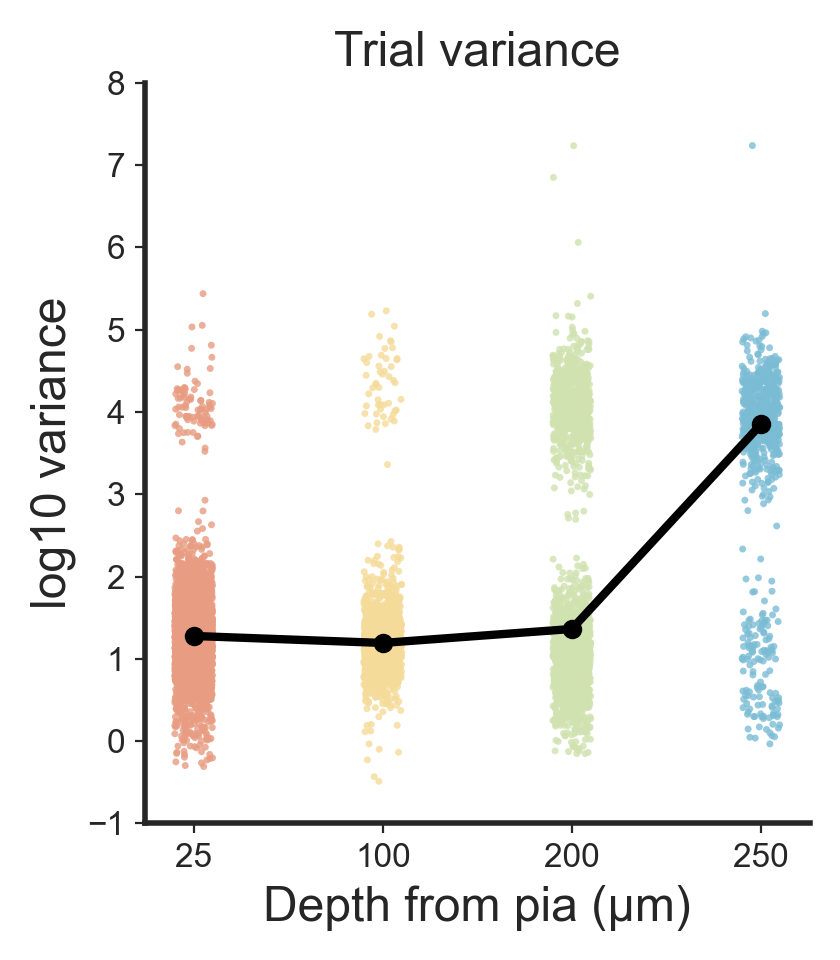

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_16636\356661775.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


In [23]:

cl, cmap, cp = PNW_cmap.get_PNW_cmap('Sailboat', n_colors=max(len(depth_order), 1))
palette = cp[::-1][:len(depth_order)]

fig, ax = plt.subplots(figsize=(4.2, 4.8))

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

for spine in ['left', 'right', 'top', 'bottom']:
    ax.spines[spine].set_linewidth(2)

sns.despine()

plot_df = variance_df.dropna(subset=['log10_within_image_var']).copy()

sns.stripplot(
    data=plot_df,
    x='depth',
    y='log10_within_image_var',
    order=depth_order,
    palette=palette,
    size=2.5,
    alpha=0.8,
    ax=ax,
)

medians = (
    plot_df.groupby('depth', observed=False)['log10_within_image_var']
    .median()
    .reindex(depth_order)
    .values
)
ax.plot(range(len(depth_order)), medians, color='k', lw=3, marker='o', zorder=20)

ax.set_xlabel('Depth from pia (μm)')
ax.set_ylabel('log10 variance')
ax.set_title('Trial variance')
ax.set_ylim(-1,8)
fig.tight_layout()

filen = 'within_image_variance_by_depth'
save_figure(fig, os.path.join(savepath, filen), formats=['.pdf', '.png'], dpi=300)


In [24]:
# ------------------------------------------------------------
# Pairwise depth comparisons
# ------------------------------------------------------------
depth_order = [25, 100, 200, 250]

pairwise_rows = []

for d1, d2 in itertools.combinations(depth_order, 2):
    x = plot_df.loc[plot_df["depth"] == d1, "log10_within_image_var"].dropna().to_numpy()
    y = plot_df.loc[plot_df["depth"] == d2, "log10_within_image_var"].dropna().to_numpy()

    if len(x) == 0 or len(y) == 0:
        continue

    stat, p = mannwhitneyu(x, y, alternative="two-sided")

    pairwise_rows.append(
        {
            "depth_1": d1,
            "depth_2": d2,
            "n_1": len(x),
            "n_2": len(y),
            "median_1": np.median(x),
            "median_2": np.median(y),
            "mean_1": np.mean(x),
            "mean_2": np.mean(y),
            "mw_u": stat,
            "p_uncorrected": p,
        }
    )

pairwise_stats = pd.DataFrame(pairwise_rows)

# ------------------------------------------------------------
# Multiple-comparisons correction
# ------------------------------------------------------------
reject, p_fdr, _, _ = multipletests(
    pairwise_stats["p_uncorrected"].values,
    alpha=0.05,
    method="fdr_bh",
)

pairwise_stats["p_fdr_bh"] = p_fdr
pairwise_stats["significant_fdr_bh"] = reject

pairwise_stats = pairwise_stats.sort_values("p_fdr_bh").reset_index(drop=True)

pairwise_stats

,depth_1,depth_2,n_1,n_2,median_1,median_2,mean_1,mean_2,mw_u,p_uncorrected,p_fdr_bh,significant_fdr_bh
0,25,250,3465,668,1.277757,3.848230,1.329225,3.364432,351397.0,3.742018e-179,2.245211e-178,True
1,100,250,1128,668,1.192826,3.848230,1.326606,3.364432,120867.0,3.264126e-128,9.792377e-128,True
2,200,250,1731,668,1.362608,3.848230,2.134543,3.364432,360395.0,1.656616e-46,3.313232e-46,True
3,25,200,3465,1731,1.277757,1.362608,1.329225,2.134543,2564585.0,1.559097e-17,2.338645e-17,True
4,100,200,1128,1731,1.192826,1.362608,1.326606,2.134543,796930.0,9.246408e-17,1.109569e-16,True
5,25,100,3465,1128,1.277757,1.192826,1.329225,1.326606,2147592.0,5.794414e-07,5.794414e-07,True


<IPython.core.display.Javascript object>


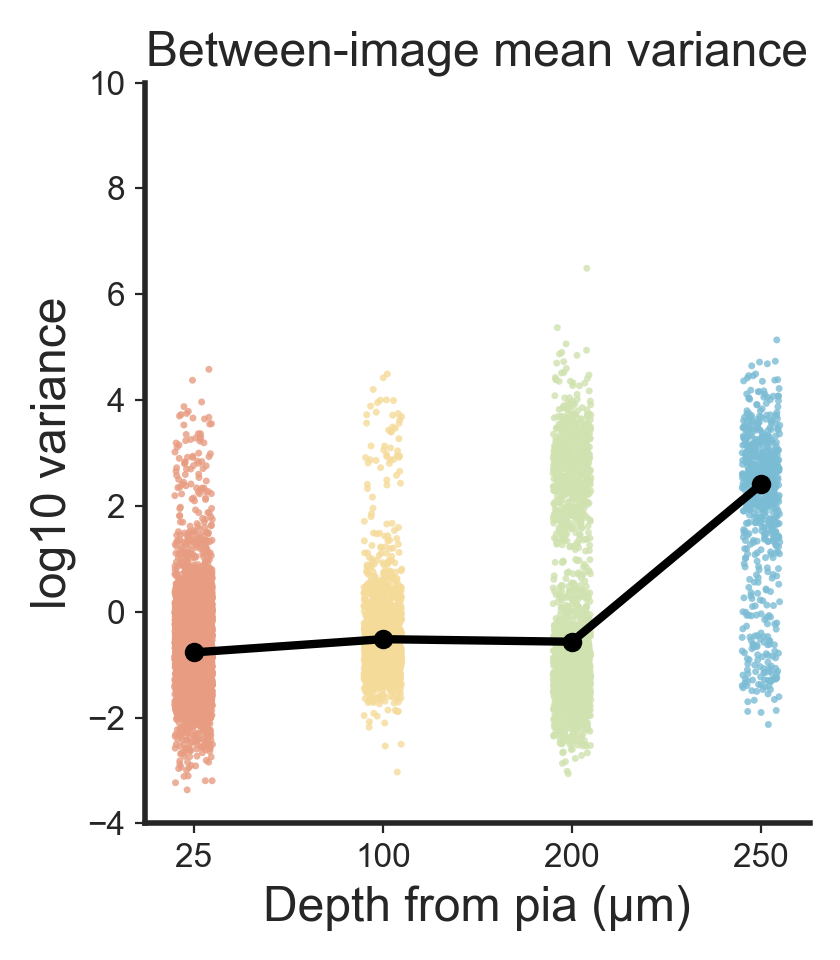

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_16636\1525685025.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


In [25]:

fig, ax = plt.subplots(figsize=(4.2, 4.8))

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

for spine in ['left', 'right', 'top', 'bottom']:
    ax.spines[spine].set_linewidth(2)

sns.despine()

plot_df = variance_df.dropna(subset=['log10_between_image_var']).copy()

sns.stripplot(
    data=plot_df,
    x='depth',
    y='log10_between_image_var',
    order=depth_order,
    palette=palette,
    size=2.5,
    alpha=0.8,
    ax=ax,
)

medians = (
    plot_df.groupby('depth', observed=False)['log10_between_image_var']
    .median()
    .reindex(depth_order)
    .values
)
ax.plot(range(len(depth_order)), medians, color='k', lw=3, marker='o', zorder=20)

ax.set_xlabel('Depth from pia (μm)')
ax.set_ylabel('log10 variance')
ax.set_title('Between-image mean variance')
ax.set_ylim(-4,10)
fig.tight_layout()

filen = 'between_image_variance_by_depth'
save_figure(fig, os.path.join(savepath, filen), formats=['.pdf', '.png'], dpi=300)


In [26]:
# ------------------------------------------------------------
# Pairwise depth comparisons
# ------------------------------------------------------------
depth_order = [25, 100, 200, 250]

pairwise_rows = []

for d1, d2 in itertools.combinations(depth_order, 2):
    x = plot_df.loc[plot_df["depth"] == d1, "log10_between_image_var"].dropna().to_numpy()
    y = plot_df.loc[plot_df["depth"] == d2, "log10_between_image_var"].dropna().to_numpy()

    if len(x) == 0 or len(y) == 0:
        continue

    stat, p = mannwhitneyu(x, y, alternative="two-sided")

    pairwise_rows.append(
        {
            "depth_1": d1,
            "depth_2": d2,
            "n_1": len(x),
            "n_2": len(y),
            "median_1": np.median(x),
            "median_2": np.median(y),
            "mean_1": np.mean(x),
            "mean_2": np.mean(y),
            "mw_u": stat,
            "p_uncorrected": p,
        }
    )

pairwise_stats = pd.DataFrame(pairwise_rows)

# ------------------------------------------------------------
# Multiple-comparisons correction
# ------------------------------------------------------------
reject, p_fdr, _, _ = multipletests(
    pairwise_stats["p_uncorrected"].values,
    alpha=0.05,
    method="fdr_bh",
)

pairwise_stats["p_fdr_bh"] = p_fdr
pairwise_stats["significant_fdr_bh"] = reject

pairwise_stats = pairwise_stats.sort_values("p_fdr_bh").reset_index(drop=True)

pairwise_stats

,depth_1,depth_2,n_1,n_2,median_1,median_2,mean_1,mean_2,mw_u,p_uncorrected,p_fdr_bh,significant_fdr_bh
0,25,250,3465,668,-0.767887,2.406030,-0.641357,1.974225,248906.0,4.714389e-227,2.828633e-226,True
1,100,250,1128,668,-0.517416,2.406030,-0.317923,1.974225,107187.0,4.551464e-142,1.365439e-141,True
2,200,250,1731,668,-0.565690,2.406030,0.285642,1.974225,312233.0,1.819359e-68,3.638718e-68,True
3,25,100,3465,1128,-0.767887,-0.517416,-0.641357,-0.317923,1564535.0,7.123369e-24,1.068505e-23,True
4,25,200,3465,1731,-0.767887,-0.565690,-0.641357,0.285642,2513477.0,1.643300e-21,1.971961e-21,True
5,100,200,1128,1731,-0.517416,-0.565690,-0.317923,0.285642,954784.0,3.189453e-01,3.189453e-01,False


In [28]:
plot_df[plot_df['log10_within_image_var']>3]

,session_id,dmd,synapse_id,within_image_var,between_image_var,total_trial_var,n_images_used,mean_trials_per_image,within_frac_total,within_to_between_ratio,...,p_value,response_class,q_value_within_synapse,session_type,depth,log10_within_image_var,log10_between_image_var,log10_total_trial_var,log10_within_frac_total,log10_within_to_between_ratio
619,803496_2025-07-30_10-05-23,DMD2,DMD2_syn0066,12191.291612,71.242495,11967.952476,7,325.142857,1.018661,171.123872,...,1.172383e-08,activated,3.517148e-08,novel,100,4.086050,1.852739,4.078020,0.008030,2.233311
2577,810196_2025-07-28_19-59-05,DMD1,DMD1_syn0000,8600.111318,689.664541,9434.905923,7,325.428571,0.911521,12.469992,...,6.575104e-145,activated,1.972531e-144,familiar,25,3.934504,2.838638,3.974738,-0.040234,1.095866
2578,810196_2025-07-28_19-59-05,DMD1,DMD1_syn0001,46108.226218,9241.269295,53949.713734,7,325.428571,0.854652,4.989382,...,6.791938e-17,activated,2.037581e-16,familiar,25,4.663778,3.965732,4.731989,-0.068211,0.698047
2579,810196_2025-07-28_19-59-05,DMD1,DMD1_syn0002,14350.827110,169.107848,14509.480938,7,325.428571,0.989066,84.861982,...,4.725074e-01,no_change,4.725074e-01,familiar,25,4.156877,2.228164,4.161652,-0.004775,1.928713
2580,810196_2025-07-28_19-59-05,DMD1,DMD1_syn0003,8833.491161,827.452629,9623.372233,7,325.428571,0.917921,10.675525,...,2.096203e-31,activated,6.288608e-31,familiar,25,3.946132,2.917743,3.983327,-0.037195,1.028389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4396,803121_2025-11-01_19-00-21,DMD2,DMD2_syn0097,9259.696824,581.686801,9610.574258,7,309.571429,0.963490,15.918699,...,3.000361e-11,deactivated,9.001082e-11,novel,250,3.966597,2.764689,3.982749,-0.016153,1.201908
4397,803121_2025-11-01_19-00-21,DMD2,DMD2_syn0098,17631.239579,5196.862690,23617.837213,7,309.571429,0.746522,3.392670,...,2.319882e-204,activated,6.959645e-204,novel,250,4.246283,3.715741,4.373240,-0.126957,0.530542
4398,803121_2025-11-01_19-00-21,DMD2,DMD2_syn0099,10516.763337,888.728182,11108.884847,7,309.571429,0.946698,11.833498,...,2.549544e-107,activated,7.648631e-107,novel,250,4.021882,2.948769,4.045670,-0.023788,1.073113
4399,803121_2025-11-01_19-00-21,DMD2,DMD2_syn0100,7287.833870,1292.515201,8381.797997,7,309.571429,0.869483,5.638490,...,4.380880e-304,activated,1.314264e-303,novel,250,3.862598,3.111436,3.923337,-0.060739,0.751163


In [18]:

# Optional: save the per-synapse table for later use in plotting or stats
out_csv = r"C:\Users\andrew.shelton\Downloads\synapse_variability_summary.csv"
variance_df.to_csv(out_csv, index=False)
print(out_csv)


C:\Users\andrew.shelton\Downloads\synapse_variability_summary.csv
